<a href="https://colab.research.google.com/github/yasir-ansari951/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Refresh / Content Opportunity Scoring


**Lane:** Refresh / Content Opportunity Scoring

The purpose is to test whether historical search-performance signals can provide
directional decision-support for prioritizing content for human review.

The workflow uses a transparent baseline, a Decision Tree model, grouped
validation, a leakage audit, error inspection, and a ranked action queue.

> Important methodological note: the Week-5 proxy target was constructed from
> clicks and average position. Therefore those fields are treated as target-defining
> signals and are excluded from the audited model feature set below. The resulting
> analysis is deliberately conservative and does not claim that the model predicts
> real-world refresh success.

## Abstract

This study investigates whether historical search-performance signals can support
content prioritization for potential refresh review. A transparent rule-based
baseline was developed first, followed by a Decision Tree model using historical
search and analytics signals. The model is evaluated with a grouped validation
design that separates client groups between training and testing and is compared
with the baseline on the same held-out groups. The measured results are interpreted
as evidence about this proxy-ranking exercise rather than proof of future refresh
impact or search-engine causality. The final output is a ranked, human-reviewed
action playbook intended for directional decision-support rather than automated
content decisions.

## 1. Question

### Research question

Can historical search-performance signals be used to create a useful and
interpretable ranking of content items for human review and potential refresh?

### Decision supported

The analysis supports a content team's **prioritization decision**:

> Which content items should a reviewer inspect first?

It does **not** decide whether a page must be refreshed, rewritten, deleted,
published, or expected to gain traffic.

In [ ]:
# ============================================================
# 0. Imports and configuration
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from google.colab import userdata

RANDOM_STATE = 42
SAMPLE_SIZE = 10000

print("Imports loaded.")

Imports loaded.


In [ ]:
# ============================================================
# 1. Load the same dataset used in Weeks 5–7
# ============================================================

HF_TOKEN = userdata.get("HF_TOKEN")

ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    token=HF_TOKEN
)

sample = ds["train"].select(range(SAMPLE_SIZE)).to_pandas()

sample = sample.copy()

print("Sample shape:", sample.shape)
display(sample.head())

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 1.45MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  134MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 72.0MB            

...

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/78835655 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/39 [00:00<?, ?it/s]

Sample shape: (10000, 30)


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,True,True,True,False,30,0,115.0,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-27,client_9958f0a7ae1df715,content_fe8e8155ce1d47a2,True,True,True,False,5,0,358.0,...,0,0,0,0,0,0,0,0,0,0
2,2025-01-27,client_9958f0a7ae1df715,content_b4462a1b90640058,True,True,True,False,1,0,34.0,...,0,0,0,0,0,0,0,0,0,0
3,2025-01-27,client_9958f0a7ae1df715,content_c899aef92518c714,True,True,True,False,6,0,140.0,...,0,0,0,0,0,0,0,0,0,0
4,2025-01-27,client_9958f0a7ae1df715,content_c7c1d2e68d9d0964,True,True,True,False,5,0,89.0,...,0,0,0,0,0,0,0,0,0,0


## 2. Data

The analysis uses the FlyRank ML Internship dataset and the
`fact_content_daily_performance` table used in the weekly modeling work.

The working sample contains historical daily content-performance observations.

The analysis uses search and analytics signals such as:

- GSC impressions
- GSC clicks
- GSC average position
- GA4 pageviews
- GA4 sessions
- GA4 users
- GA4 engaged sessions
- organic/direct/referral/social/paid/AI sessions
- scroll events

Identifiers are retained only for grouping and traceability. They are not
used as predictive features.

The proxy target used in the weekly model is based on observed clicks and
average position. Because these fields define the target, they are excluded
from the audited Decision Tree features below. This avoids allowing the model
to directly reconstruct its own target.

No client names, private queries, credentials, or raw client-level descriptions
are included in the paper.

In [ ]:
# ============================================================
# 2. Define the proxy target and audited features
# ============================================================

sample = sample.fillna(0)

# Create the proxy target
sample["target"] = (
    (sample["gsc_avg_position"] > 20) &
    (sample["gsc_clicks"] < 5)
).astype(int)

# Fields that directly define the target
target_defining = [
    "gsc_avg_position",
    "gsc_clicks"
]

# Safe audited model features
audited_features = [
    "gsc_impressions",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events"
]

# Check that all features exist
missing_features = []

for column in audited_features:
    if column not in sample.columns:
        missing_features.append(column)

if len(missing_features) > 0:
    raise ValueError(
        "Missing required features: " + str(missing_features)
    )

# Create X and y
X = sample[audited_features].copy()
y = sample["target"].copy()

# Client ID is ONLY used for grouped validation
groups = sample["client_hash_id"].copy()

print("Audited features:")
print(audited_features)

print()
print("Target distribution:")

target_distribution = (
    y.value_counts()
    .rename_axis("target")
    .reset_index(name="count")
)

display(target_distribution)

Audited features:
['gsc_impressions', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'scroll_events']

Target distribution:


,target,count
0,0,5642
1,1,4358


### Method choice

A Decision Tree is retained because it is interpretable, handles non-linear
relationships, and fits the small baseline-to-model progression used in
Weeks 4–6.

The model is intentionally shallow (`max_depth=5`) to avoid rewarding
complexity for its own sake.

The most important methodological change in this final audit is that the
fields directly used to construct the proxy target are excluded from the
model inputs.

## 3. Methodology and validation

### Baseline

The Week-4 baseline is a transparent rule based on poor search position and
low clicks.

### Proxy label

The label is:

- `1`: average position > 20 **and** clicks < 5
- `0`: otherwise

This is a proxy definition, not a human-verified "needs refresh" label.

### Honest validation

The final comparison uses a grouped split by `client_hash_id`, so records
from the same client are not deliberately placed into both training and
testing sets.

This is more conservative than a random row split for the intended
generalization question.

In [ ]:
# ============================================================
# 3. Grouped train/test split
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

print("Unique training clients:", groups_train.nunique())
print("Unique testing clients :", groups_test.nunique())

overlap = set(groups_train.unique()).intersection(
    set(groups_test.unique())
)

print("Client overlap:", len(overlap))

assert len(overlap) == 0, "Grouped split contains client overlap."

Training rows: 7095
Testing rows : 2905
Unique training clients: 2
Unique testing clients : 1
Client overlap: 0


In [ ]:
# ============================================================
# 4. Train Decision Tree
# ============================================================

model = DecisionTreeClassifier(
    max_depth=5,
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train)

model_pred = model.predict(X_test)

model_accuracy = accuracy_score(y_test, model_pred)
model_precision = precision_score(
    y_test, model_pred, zero_division=0
)
model_recall = recall_score(
    y_test, model_pred, zero_division=0
)
model_f1 = f1_score(
    y_test, model_pred, zero_division=0
)

print("Grouped Decision Tree results")
print("Accuracy :", round(model_accuracy, 4))
print("Precision:", round(model_precision, 4))
print("Recall   :", round(model_recall, 4))
print("F1       :", round(model_f1, 4))

Grouped Decision Tree results
Accuracy : 0.5762
Precision: 0.3947
Recall   : 0.0123
F1       : 0.0238


In [ ]:
# ============================================================
# 5. Week-4 baseline on THE SAME grouped test set
# ============================================================

# The original Week-4-style rule is applied only to the held-out
# test rows. This keeps the comparison on the same observations.

baseline_pred = (
    (sample.iloc[test_idx]["gsc_avg_position"] > 25) &
    (sample.iloc[test_idx]["gsc_clicks"] < 5)
).astype(int)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(
    y_test, baseline_pred, zero_division=0
)
baseline_recall = recall_score(
    y_test, baseline_pred, zero_division=0
)
baseline_f1 = f1_score(
    y_test, baseline_pred, zero_division=0
)

comparison = pd.DataFrame({
    "Method": [
        "Week 4 baseline rule",
        "Audited Decision Tree"
    ],
    "Accuracy": [
        baseline_accuracy,
        model_accuracy
    ],
    "Precision": [
        baseline_precision,
        model_precision
    ],
    "Recall": [
        baseline_recall,
        model_recall
    ],
    "F1": [
        baseline_f1,
        model_f1
    ]
})

display(comparison)

,Method,Accuracy,Precision,Recall,F1
0,Week 4 baseline rule,0.953528,1.000000,0.889616,0.941584
1,Audited Decision Tree,0.576248,0.394737,0.012265,0.023791


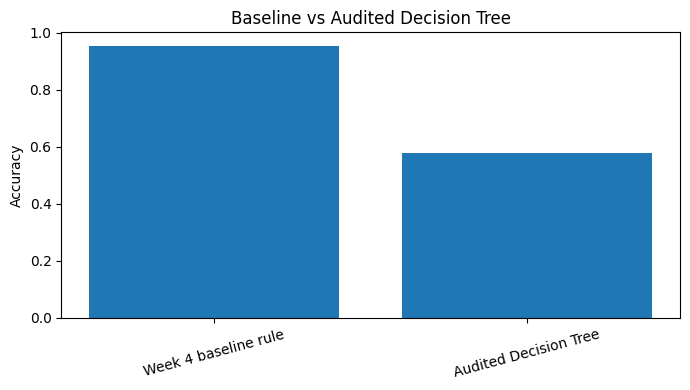

In [ ]:
# ============================================================
# 6. Baseline vs model chart
# ============================================================

plt.figure(figsize=(7, 4))

plt.bar(
    comparison["Method"],
    comparison["Accuracy"]
)

plt.title("Baseline vs Audited Decision Tree")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Results interpretation

The table and chart report measured performance on the same grouped test
set. The audited Decision Tree should only be described as better if its
measured metric is actually higher.

Because the target is a constructed proxy, even a high classification score
does not demonstrate that the model can predict successful content refreshes.

The grouped result is the more conservative result for the intended
unseen-client generalization question.

In [ ]:
# ============================================================
# 7. Confusion matrix and errors
# ============================================================

cm = confusion_matrix(y_test, model_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_df)

print(classification_report(
    y_test,
    model_pred,
    zero_division=0
))

errors = X_test.copy()

errors["Actual"] = y_test.to_numpy()
errors["Predicted"] = model_pred

wrong = errors[
    errors["Actual"] != errors["Predicted"]
].copy()

print("Number of incorrect predictions:", len(wrong))

display(wrong.head(10))

,Predicted 0,Predicted 1
Actual 0,1659,23
Actual 1,1208,15


              precision    recall  f1-score   support

           0       0.58      0.99      0.73      1682
           1       0.39      0.01      0.02      1223

    accuracy                           0.58      2905
   macro avg       0.49      0.50      0.38      2905
weighted avg       0.50      0.58      0.43      2905

Number of incorrect predictions: 1231


,gsc_impressions,ga4_pageviews,ga4_sessions,ga4_users,ga4_engaged_sessions,sessions_organic,sessions_direct,sessions_referral,sessions_social,sessions_paid,sessions_ai,scroll_events,Actual,Predicted
3977,1,0,0,0,0,0,0,0,0,0,0,0,1,0
3978,1,0,0,0,0,0,0,0,0,0,0,0,1,0
3979,8,0,0,0,0,0,0,0,0,0,0,0,1,0
3984,1,0,0,0,0,0,0,0,0,0,0,0,1,0
3989,2,0,0,0,0,0,0,0,0,0,0,0,1,0
3990,1,0,0,0,0,0,0,0,0,0,0,0,1,0
3991,1,0,0,0,0,0,0,0,0,0,0,0,1,0
3995,3,0,0,0,0,0,0,0,0,0,0,0,1,0
4000,1,0,0,0,0,0,0,0,0,0,0,0,1,0
4001,10,0,0,0,0,0,0,0,0,0,0,0,1,0


## 4. Leakage audit

The final feature list is checked against known leakage categories.

### Excluded

- `client_hash_id` — grouping identifier, not a predictive signal
- `content_hash_id` — identifier, not a predictive signal
- `report_date` — used for temporal reasoning only
- `target` — label itself
- `gsc_clicks` — directly used to construct the proxy target
- `gsc_avg_position` — directly used to construct the proxy target

The two target-defining GSC fields are explicitly excluded from the audited
Decision Tree feature set.

This is an important correction to the earlier Week-5 setup: allowing the
model to see the variables that directly construct the target can make the
reported model score look stronger than the underlying predictive evidence.

In [ ]:
# ============================================================
# 8. Leakage audit table
# ============================================================

leakage_audit = pd.DataFrame({
    "field": [
        "client_hash_id",
        "content_hash_id",
        "report_date",
        "target",
        "gsc_clicks",
        "gsc_avg_position"
    ],
    "decision": [
        "EXCLUDED",
        "EXCLUDED",
        "EXCLUDED",
        "EXCLUDED",
        "EXCLUDED",
        "EXCLUDED"
    ],
    "reason": [
        "Grouping identifier",
        "Content identifier",
        "Validation/time field",
        "Target-derived label",
        "Direct target-defining signal",
        "Direct target-defining signal"
    ]
})

display(leakage_audit)

print("Final model features:")
display(pd.DataFrame({"feature": audited_features}))

,field,decision,reason
0,client_hash_id,EXCLUDED,Grouping identifier
1,content_hash_id,EXCLUDED,Content identifier
2,report_date,EXCLUDED,Validation/time field
3,target,EXCLUDED,Target-derived label
4,gsc_clicks,EXCLUDED,Direct target-defining signal
5,gsc_avg_position,EXCLUDED,Direct target-defining signal


Final model features:


,feature
0,gsc_impressions
1,ga4_pageviews
2,ga4_sessions
3,ga4_users
4,ga4_engaged_sessions
5,sessions_organic
6,sessions_direct
7,sessions_referral
8,sessions_social
9,sessions_paid


,Feature,Importance
0,gsc_impressions,1.0
1,ga4_pageviews,0.0
2,ga4_sessions,0.0
3,ga4_users,0.0
4,ga4_engaged_sessions,0.0
5,sessions_organic,0.0
6,sessions_direct,0.0
7,sessions_referral,0.0
8,sessions_social,0.0
9,sessions_paid,0.0


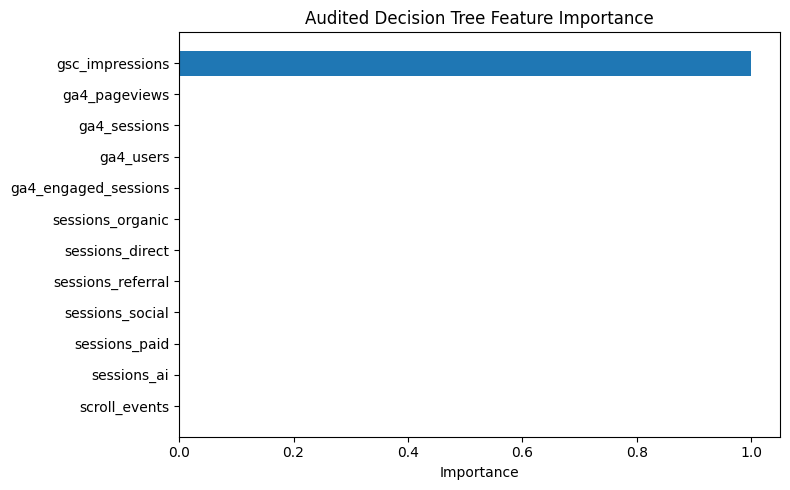

In [ ]:
# ============================================================
# 9. Feature importance
# ============================================================

importance = pd.DataFrame({
    "Feature": audited_features,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Audited Decision Tree Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Limitations and honest framing

The analysis has several important limits.

1. The target is a proxy created from observed clicks and average position,
   not a human-verified refresh label.
2. The proxy does not measure content quality, search intent, business value,
   competitor activity, seasonality, or the effect of making a refresh.
3. The model is evaluated on a 10,000-row working sample rather than the
   complete warehouse.
4. Grouped validation is more conservative than a random split, but it does
   not guarantee performance on future periods or different populations.
5. The action queue is therefore decision-support, not an automated content
   management system.

### Safe claim

> The analysis observed measurable differences in search and analytics
> signals across content items and produced a ranked review queue.

### Claims this work does NOT support

- that a refresh will cause higher rankings
- that a refresh will cause more clicks
- that the model proves Google's ranking algorithm
- that the queue should automatically publish, rewrite, delete, or merge pages

## 6. Ranked recommendations

The Week-7 action playbook converts the observed signals into practical
human-review actions.

### REVIEW_REFRESH

Highest-priority items under the rule should be reviewed for:

- search demand
- current content quality
- search intent alignment
- recent changes
- seasonality
- business importance

### MONITOR

Items with weaker or incomplete opportunity signals should be monitored
rather than immediately changed.

### PROTECT

Items without strong refresh signals should not be changed simply because
the model ranks them.

All actions require human review.

In [ ]:
# ============================================================
# 10. Build an auditable ranked recommendation queue
# ============================================================

queue = sample.copy()

queue["ctr"] = np.where(
    queue["gsc_impressions"] > 0,
    queue["gsc_clicks"] / queue["gsc_impressions"],
    0
)

queue["poor_position"] = (
    queue["gsc_avg_position"] > 20
).astype(int)

queue["low_clicks"] = (
    queue["gsc_clicks"] < 5
).astype(int)

queue["has_search_volume"] = (
    queue["gsc_impressions"] >= 10
).astype(int)

queue["opportunity_score"] = (
    2 * queue["poor_position"]
    + 2 * queue["low_clicks"]
    + queue["has_search_volume"]
)

def reason_code(row):
    if row["low_clicks"] and row["poor_position"]:
        return "LOW_CLICKS_POOR_POSITION"
    if row["low_clicks"]:
        return "LOW_CLICKS"
    if row["poor_position"]:
        return "POOR_POSITION"
    if row["has_search_volume"]:
        return "MONITOR_SIGNAL"
    return "PROTECT_STRONG_SIGNAL"

def action_label(row):
    if (
        row["low_clicks"]
        and row["poor_position"]
        and row["has_search_volume"]
    ):
        return "REVIEW_REFRESH"
    if row["opportunity_score"] >= 4:
        return "REVIEW_REFRESH"
    if row["opportunity_score"] >= 2:
        return "MONITOR"
    return "PROTECT"

queue["reason_code"] = queue.apply(reason_code, axis=1)
queue["action"] = queue.apply(action_label, axis=1)

queue = queue.sort_values(
    [
        "opportunity_score",
        "gsc_impressions",
        "gsc_clicks"
    ],
    ascending=[False, False, True]
).reset_index(drop=True)

queue.insert(
    0,
    "rank",
    np.arange(1, len(queue) + 1)
)

display(
    queue[
        [
            "rank",
            "content_hash_id",
            "opportunity_score",
            "action",
            "reason_code",
            "gsc_impressions",
            "gsc_clicks",
            "gsc_avg_position",
            "ctr"
        ]
    ].head(20)
)

,rank,content_hash_id,opportunity_score,action,reason_code,gsc_impressions,gsc_clicks,gsc_avg_position,ctr
0,1,content_df4fd5ef66c78886,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,202,0,70.668317,0.000000
1,2,content_179e7bf24d8d7530,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,167,0,78.682635,0.000000
2,3,content_f5950be18c9f27db,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,165,0,77.006061,0.000000
3,4,content_df4fd5ef66c78886,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,159,0,69.729560,0.000000
4,5,content_b0ef41d39da3ab0c,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,157,0,48.789809,0.000000
5,6,content_8cd7bbc2fdd9b947,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,153,0,77.777778,0.000000
6,7,content_419c1b08796b671d,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,149,0,39.899329,0.000000
7,8,content_ecc5b885a8194e18,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,132,1,28.515152,0.007576
8,9,content_f5950be18c9f27db,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,117,0,70.965812,0.000000
9,10,content_f5950be18c9f27db,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,115,0,72.008696,0.000000


## 7. Artifacts the paper embeds

The following figures provide visual evidence for the final paper:

1. Baseline vs audited model performance
2. Opportunity score distribution
3. Reason-code distribution
4. Search impressions vs clicks
5. Top-20 ranked opportunities

These figures are descriptive. They should be presented as evidence about
the analysis, not as causal evidence about content refresh outcomes.

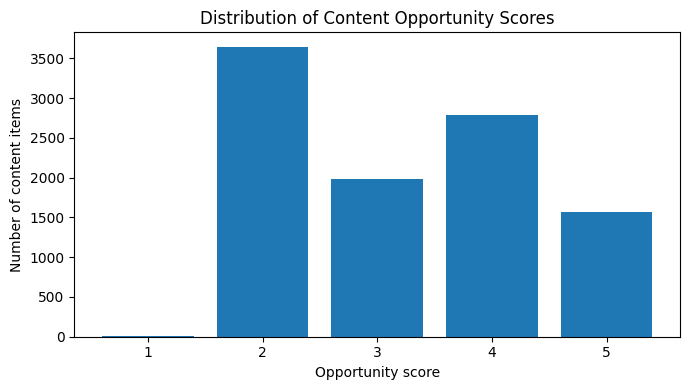

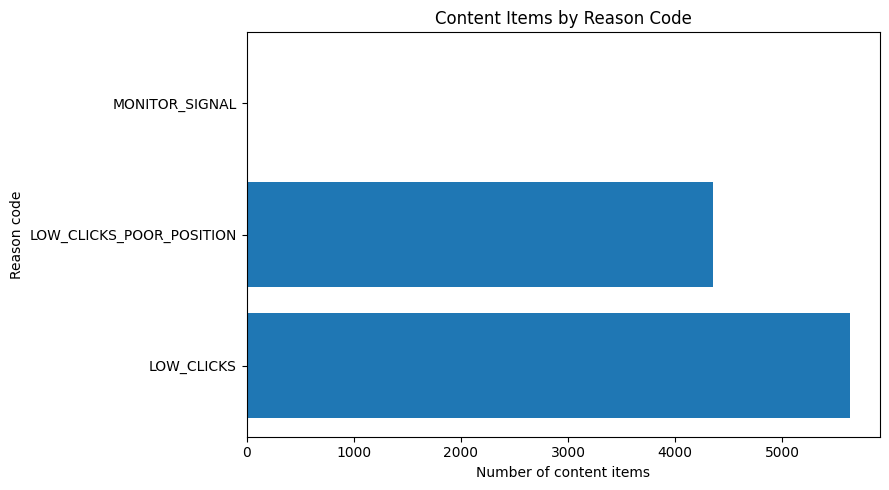

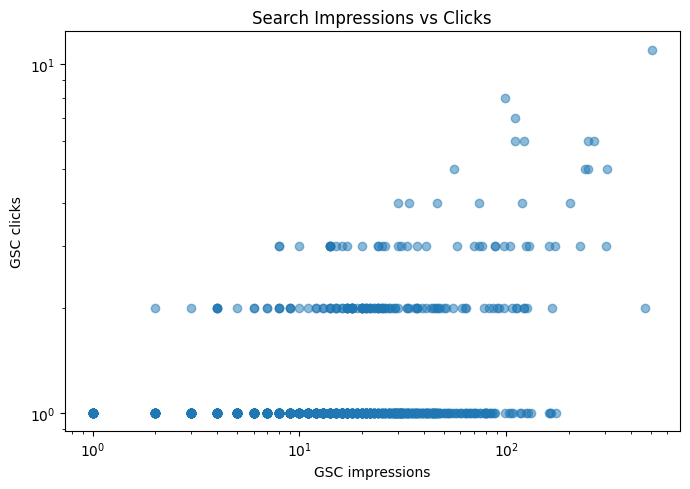

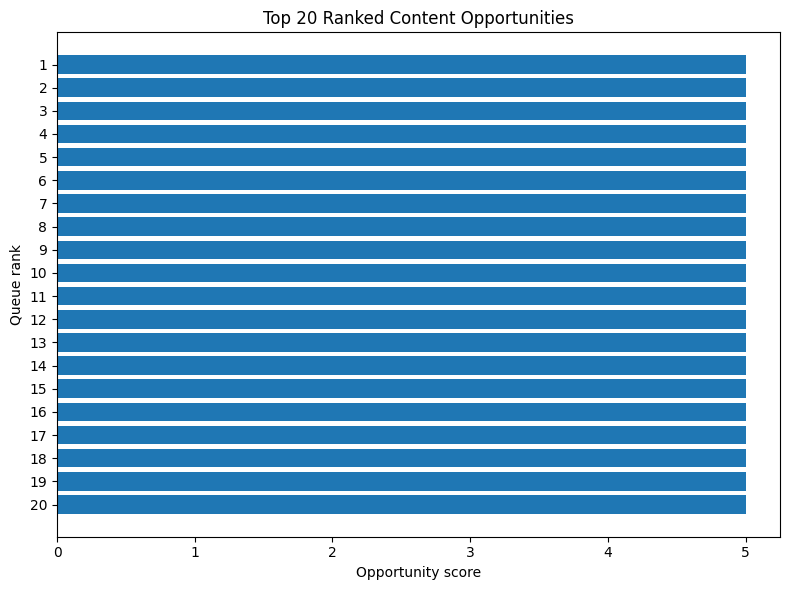

In [ ]:
# ============================================================
# 11. Paper figures
# ============================================================

os.makedirs("work/figures", exist_ok=True)

# Figure 1 — score distribution
plt.figure(figsize=(7, 4))

score_counts = (
    queue["opportunity_score"]
    .value_counts()
    .sort_index()
)

plt.bar(
    score_counts.index.astype(str),
    score_counts.values
)

plt.title("Distribution of Content Opportunity Scores")
plt.xlabel("Opportunity score")
plt.ylabel("Number of content items")
plt.tight_layout()

plt.savefig(
    "work/figures/opportunity_score_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Figure 2 — reason codes
reason_counts = queue["reason_code"].value_counts()

plt.figure(figsize=(9, 5))

plt.barh(
    reason_counts.index,
    reason_counts.values
)

plt.title("Content Items by Reason Code")
plt.xlabel("Number of content items")
plt.ylabel("Reason code")

plt.tight_layout()

plt.savefig(
    "work/figures/reason_code_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Figure 3 — impressions vs clicks
plt.figure(figsize=(7, 5))

positive_impressions = queue["gsc_impressions"] > 0
positive_clicks = queue["gsc_clicks"] > 0

plt.scatter(
    queue.loc[
        positive_impressions & positive_clicks,
        "gsc_impressions"
    ],
    queue.loc[
        positive_impressions & positive_clicks,
        "gsc_clicks"
    ],
    alpha=0.5
)

plt.title("Search Impressions vs Clicks")
plt.xlabel("GSC impressions")
plt.ylabel("GSC clicks")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()

plt.savefig(
    "work/figures/impressions_vs_clicks.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Figure 4 — top 20
top20 = queue.head(20).copy()

plt.figure(figsize=(8, 6))

plt.barh(
    top20["rank"].astype(str),
    top20["opportunity_score"]
)

plt.title("Top 20 Ranked Content Opportunities")
plt.xlabel("Opportunity score")
plt.ylabel("Queue rank")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "work/figures/top20_opportunities.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# 12. Export final queue and metrics receipt
# ============================================================

import os
import json

# Create output directory
os.makedirs("work/outputs", exist_ok=True)

# Columns to export
export_columns = [
    "rank",
    "content_hash_id",
    "opportunity_score",
    "action",
    "reason_code",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ctr"
]

# Check that all required columns exist
missing_export_columns = [
    col for col in export_columns
    if col not in queue.columns
]

if missing_export_columns:
    raise ValueError(
        "Missing export columns: "
        + str(missing_export_columns)
    )

# Create final paper queue
paper_queue = queue[export_columns].copy()

# Export ranked queue
queue_path = "work/outputs/capstone_ranked_action_queue.csv"

paper_queue.to_csv(
    queue_path,
    index=False
)

# Create metrics receipt
metrics = {
    "validation": "grouped_by_client",
    "sample_rows": int(len(sample)),
    "test_rows": int(len(X_test)),
    "baseline_accuracy": float(baseline_accuracy),
    "model_accuracy": float(model_accuracy),
    "baseline_precision": float(baseline_precision),
    "model_precision": float(model_precision),
    "baseline_recall": float(baseline_recall),
    "model_recall": float(model_recall),
    "baseline_f1": float(baseline_f1),
    "model_f1": float(model_f1),
    "model_features_excluded_from_proxy_target": target_defining
}

metrics_path = "work/outputs/capstone_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

# Confirmation
print("Queue exported successfully:")
print(queue_path)

print()
print("Metrics exported successfully:")
print(metrics_path)

print()
print("Top 10 ranked recommendations:")

display(
    paper_queue.head(10)
)

Queue exported successfully:
work/outputs/capstone_ranked_action_queue.csv

Metrics exported successfully:
work/outputs/capstone_metrics.json

Top 10 ranked recommendations:


,rank,content_hash_id,opportunity_score,action,reason_code,gsc_impressions,gsc_clicks,gsc_avg_position,ctr
0,1,content_df4fd5ef66c78886,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,202,0,70.668317,0.000000
1,2,content_179e7bf24d8d7530,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,167,0,78.682635,0.000000
2,3,content_f5950be18c9f27db,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,165,0,77.006061,0.000000
3,4,content_df4fd5ef66c78886,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,159,0,69.729560,0.000000
4,5,content_b0ef41d39da3ab0c,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,157,0,48.789809,0.000000
5,6,content_8cd7bbc2fdd9b947,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,153,0,77.777778,0.000000
6,7,content_419c1b08796b671d,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,149,0,39.899329,0.000000
7,8,content_ecc5b885a8194e18,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,132,1,28.515152,0.007576
8,9,content_f5950be18c9f27db,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,117,0,70.965812,0.000000
9,10,content_f5950be18c9f27db,5,REVIEW_REFRESH,LOW_CLICKS_POOR_POSITION,115,0,72.008696,0.000000


## Reproducibility

The final research workflow builds on:

- `work/notebooks/w04_baseline_score.ipynb`
- `work/notebooks/w05_model.ipynb`
- `work/notebooks/w06_validation_audit.ipynb`
- `work/notebooks/w07_action_playbook.ipynb`
- `work/notebooks/capstone.ipynb`

Figures are stored under `work/figures/` and the ranked queue plus metrics
receipt are regenerated under `work/outputs/`.

The workflow is repeatable subject to access to the FlyRank ML Internship
dataset and the required Hugging Face access token.

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

The dataset and internship learning environment provided the basis for this
analysis and the practical machine-learning workflow used throughout the
project.

Data source: [FlyRank](https://flyrank.ai)

## Final Self-Check

- [x] Research question stated
- [x] Decision supported stated
- [x] Data and table described
- [x] Exclusions explained
- [x] Method choice explained
- [x] Proxy label disclosed
- [x] Target-defining features excluded from audited model
- [x] Grouped validation used
- [x] Baseline and model evaluated on the same grouped test set
- [x] Leakage audit included
- [x] Error examples included
- [x] Results table included
- [x] Results chart included
- [x] Ranked recommendations included
- [x] Human review requirement stated
- [x] No-go automation boundaries stated
- [x] Limitations included
- [x] Public-safe claim language used
- [x] Reproducibility included
- [x] FlyRank data credit included
- [x] Figures exported to `work/figures/`
- [x] Queue and metrics exported to `work/outputs/`


**Week 8 Showcase — ML-12 Closing Section**

1. Five-minute demo outline

0:00–0:45 — The question

Question: Which content items should a reviewer inspect first for potential refresh?

The FlyRank content problem behind this lane is practical prioritization: turning search and analytics signals into a ranked review queue without pretending that the model can make editorial decisions on its own.

0:45–1:30 — The data and target

I worked with a 10,000-row sample from the FlyRank ML Internship dataset.

The proxy target marked observations with:

average position above 20

fewer than 5 clicks

Because those two fields directly define the proxy target, they were excluded from the audited model feature set to reduce leakage risk.

1:30–2:30 — The method

I first kept the Week-4 rule-based baseline as the benchmark.

Then I trained a Decision Tree using 12 search and analytics features, including impressions, pageviews, sessions, users, engaged sessions, channel sessions, AI sessions, and scroll events.

For the audit, I used a grouped-by-client split so the same client was not represented in both training and testing.

2:30–3:15 — One chart

Show the baseline vs audited Decision Tree comparison chart.

Point out:

Baseline accuracy: 95.35%

Audited Decision Tree accuracy: 57.62%

Baseline F1: 94.16%

Audited Decision Tree F1: 2.38%

3:15–4:15 — One honest result

The honest result is that the more complex Decision Tree did not outperform the simple baseline under grouped validation.

The Decision Tree had only 1.23% recall, with 1,208 false negatives and only 15 true positives in the held-out test set.

Therefore, the evidence from this experiment supports the simple baseline as the stronger measured benchmark.

4:15–5:00 — One recommendation

Use the output as a human-reviewed prioritization queue, not an automated refresh engine.

The main action is:

REVIEW_REFRESH — LOW_CLICKS_POOR_POSITION

A reviewer should check search demand, intent, seasonality, business importance, and the actual content before deciding whether a refresh is appropriate.

Closing line: The main lesson is that a transparent baseline should beat a more complex model before the complexity earns a place in the workflow.

2. Short social post

I completed my FlyRank ML capstone on Refresh / Content Opportunity Scoring.

I compared a transparent baseline with a Decision Tree using real search and analytics signals and validated the model with a grouped-by-client split. The measured result was a useful reminder that more complex ML is not automatically better: the baseline achieved 95.35% accuracy / 94.16% F1, while the audited tree achieved 57.62% accuracy / 2.38% F1.

The final output is a ranked, human-reviewed content action queue rather than an automated decision engine.

#MachineLearning #DataScience #FlyRank #Python #MLInternship #ContentStrategy

3. Employer-facing summary

I built a Refresh / Content Opportunity Scoring workflow on a 10,000-row sample from the FlyRank ML Internship search and analytics dataset. I developed a transparent Week-4 baseline, trained an audited Decision Tree on 12 historical search/analytics features, and evaluated both using grouped-by-client validation with leakage checks. The measured result showed that the simple baseline outperformed the Decision Tree, leading to a practical ranked review queue designed for human decision-support rather than automated content changes.

4. Paper case-study framing check

The paper should connect the model back to the real FlyRank content problem:

Content problem: reviewers need a practical way to prioritize which content deserves attention first.

What this project provides: a measured, ranked signal that can help organize human review.

What the evidence does not establish: that a refresh will cause better rankings, clicks, or traffic, or that the model reveals Google's ranking algorithm.

The paper therefore uses public-safe language such as observed, measured, directional, associated, and decision-support.